In case you have troubles with some parts of the code, it might be valuable to review the Python basics that were covered in the first two weeks of the lecture.

# Main Exercise: Hyperparameter Optimization

This week, we will implement common algorithms used for hyperparameter optimization ourselves. In particular we will look into random search, grid search, and simulated annealing. We will begin by applying all three algorithms on a toy optimization problem. Subsequently, we will apply simulated annealing for hyperparameter optimization of an artificial neural network predicting the electronic energies of both the ground and the first excited state as a function of the distance between the two atoms.

### 1. Practical

We start by installing all the required libraries for this exercise. This is done with `pip`, the package installer for Python: https://pypi.org/project/pip/

Note that we need to downgrade matplotlib as one package we are using is not compatible with the most recent matplotlib version. This requires you to restart the runtime after completing the package installation.

In [ ]:
# Install required libraries
! pip install torch skorch netCDF4 matplotlib==3.10.0

Here, we load all the packages we need for the practical part.

In [ ]:
# Load all packages we will need
## Handling random seeds
import random as rd
## Handling data
import numpy as np
import pandas as pd
import netCDF4 as nc
## Utilities for probability distributions
import scipy.stats as sps
## Data science utilities
import sklearn.model_selection as skms
import sklearn.preprocessing as skpp
## Machine learning backend
import torch as tc
import torch.optim as tco
## Interfacing Torch and Scikit-Learn
import skorch as skc
import skorch.dataset as skcd
import skorch.helper as skch
## Plot results
import matplotlib.pyplot as plt
## Other utilities
from typing import Callable

For being able to obtain the exact same results when rerunning your code, it is important to set random seeds. Otherwise, as many of the methods implemented rely on stochastic processes, you will obtain different results every time you run the code.

In [ ]:
# Random Seeds for reproducibility
random_seed = 0
random_state = np.random.RandomState(random_seed)
tc.manual_seed(random_seed)
tc.cuda.manual_seed(random_seed)
np.random.seed(random_seed)
rd.seed(random_seed)
tc.use_deterministic_algorithms(True)

### Toy Problem

The toy problem involves defining a discrete double-well potential in a 4-dimensional space. The potential is defined by two wells, each with its own mean and covariance matrix. The mathematical expressions for the means and covariances are as follows:

1. **Mean of Well 1**:
   $$
   \mu_1 = \left[ \sum_{n_i=0}^{d_i+4} \frac{(-1)^{n_i+2}}{n_i+1} \right] \quad \text{for each dimension } d_i
   $$

2. **Covariance of Well 1**:
   $$
   \Sigma_1 = \text{diag}([0.05, 0.05, \dots, 0.05]) \quad \text{(diagonal matrix with 0.05 along the diagonal)}
   $$

3. **Mean of Well 2**:
   $$
   \mu_2 = \left[ \sum_{n_i=0}^{d_i+1} \frac{(-1)^{n_i+2}}{(2(n_i+1)-1) \cdot 5} \right] \quad \text{for each dimension } d_i
   $$

4. **Covariance of Well 2**:
   $$
   \Sigma_2 = \text{diag}([0.0025, 0.0025, \dots, 0.0025]) \quad \text{(diagonal matrix with 0.0025 along the diagonal)}
   $$

5. **Surface Calculation**:
   $$
   y = 5 - \frac{5}{7} \cdot \text{pdf}(X, \mu_1, \Sigma_1) - \frac{1}{650} \cdot \text{pdf}(X, \mu_2, \Sigma_2)
   $$
   where `pdf` is the probability density function of the multivariate normal distribution.

6. **Adding Noise**:
   $$
   y = \text{round}(y) + \mathcal{N}(0, \sigma^2)
   $$
   where \(\mathcal{N}(0, \sigma^2)\) represents Gaussian noise with mean 0 and variance \(\sigma^2\) (here \(\sigma = \text{noise}\)).

In [225]:
def discrete_double_well(X: np.ndarray, dimensions: int=4, noise: float=0.1) -> np.ndarray:
  """
  Calculates the energy function, being a discrete double well, on the input X.

  Args:
    X (np.ndarray): Input data in the shape [n_dimensions, product of n_points_per_dimension]
    dimensions (int): Number of dimensions
    noise (float): Amount of noise to add to the surface values
  """

  # Define well 1
  mean_1 = np.array([np.sum([(-1)**(ni+2)/(ni+1) for ni in range(di+5)]) for di in range(dimensions)])
  covariance_1 = np.diag(np.full(dimensions, 0.05))

  # Define well 2
  mean_2 = np.array([np.sum([(-1)**(ni+2)/((2*(ni+1)-1)*5) for ni in range(di+2)]) for di in range(dimensions)])
  covariance_2 = np.diag(np.full(dimensions, 0.0025))

  # Compute surface
  y: float = 5
  y -= 5 * sps.multivariate_normal.pdf(X, mean=mean_1, cov=covariance_1) / 7
  y -= sps.multivariate_normal.pdf(X, mean=mean_2, cov=covariance_2) / 650
  y: float = np.rint(y) + np.random.normal(0, noise, size=np.shape(y))

  return np.atleast_1d(y)

Next, we define the space to be optimized over. The optimization landscape is a discrete 4-dimensional grid.

In [226]:
# Define grid by number of grid points on each axis
n_a = 20
n_b = 14
n_c = 8
n_d = 7

# Define allowed grid positions on each dimension
a = np.linspace(0, 1, n_a)
b = np.linspace(0, 1, n_b)
c = np.linspace(0, 1, n_c)
d = np.linspace(0, 1, n_d)
grid_list_toy = [a, b, c, d]

To get a first idea of our optimization surface, we generate a slice along two dimensions through the surface and plot the corresponding results. This is done with the following code provided to you. The slice goes roughly through the middle of both the c and d dimensions. Importantly, as the name of the optimization surface implies (DiscreteDoubleWell), it has two minima. As you can see on the plot below, only one is observed in this slice.

Slice at c = 0.0 and d = 0.0


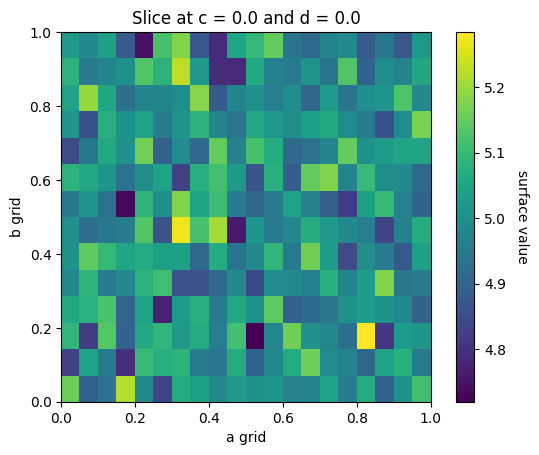

Slice at c = 0.25 and d = 0.25


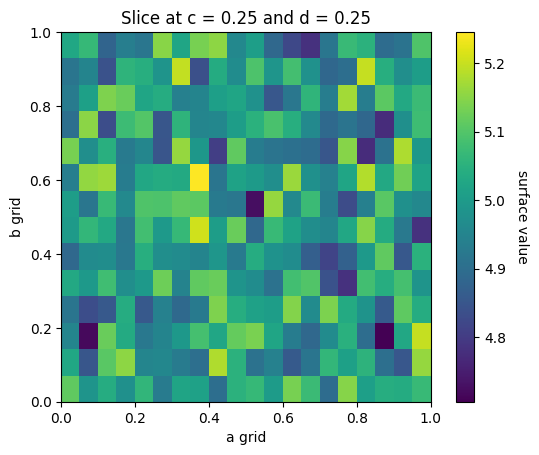

Slice at c = 0.5 and d = 0.5


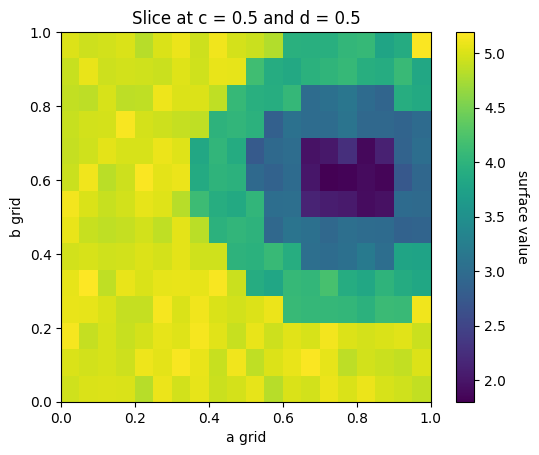

Slice at c = 0.75 and d = 0.75


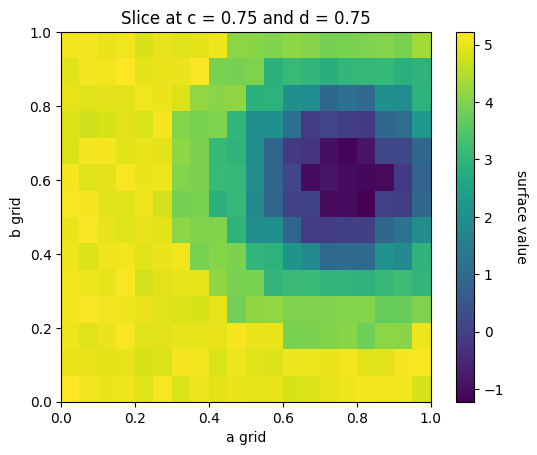

In [227]:
# Evaluate surface on a slice with 2 dimensions and visualize it
ab = np.array(np.meshgrid(a, b)).T.reshape(-1, 2) # a and b are the dimensions that are not kept constant


for slice in np.arange(0, 1, 0.25):
    print(f"Slice at c = {slice} and d = {slice}")
    # Add two missing dimensions to the grid on the slice
    ab_slice = np.stack((ab[:, 0], ab[:, 1], np.full(n_a * n_b, slice), np.full(n_a * n_b, slice)), axis=1) # slice goes through middle of space, c = 0.5 and d = 0.5

    # Evaluate surface on slice and reshape for plotting
    surface_slice = discrete_double_well(ab_slice)
    surface_slice_grid = np.array(surface_slice).reshape((n_a, n_b)).T # imshow uses the columns for the horizontal axis and the rows for the vertical axis

    # Plot slice though surface along the first two dimensions
    fig, ax = plt.subplots()
    im = ax.imshow(surface_slice_grid, interpolation='none', extent=(a[0], a[-1], b[0], b[-1]), origin='lower') # lower ensures that the origin of the vertical axis is on the lower end, default is the opposite
    cbar = plt.colorbar(im)
    cbar.set_label('surface value', rotation=270, labelpad=17)
    plt.xlabel('a grid')
    plt.ylabel('b grid')
    plt.title(f'Slice at c = {slice} and d = {slice}')
    plt.show()

In [ ]:
from typing import Protocol

dim_to_symbol = {0: 'a', 1: 'b', 2: 'c', 3: 'd'}

class SurfaceFunction(Protocol):
    def __call__(self, X: np.ndarray, dimensions: int=4, noise: float=0.1) -> np.ndarray:
        ...

def plot_slice(grid_list: list[np.ndarray], surface_function: SurfaceFunction, plot_dimensions: tuple[int, int], slice_values: tuple[float, float]):

    two_dim_grid = np.array(np.meshgrid(grid_list[plot_dimensions[0]], grid_list[plot_dimensions[1]])).T.reshape(-1, 2) # get grid for the dimensions to plot, e.g. dimensions 0 and 1 for dimensions a and b

    slice_1, slice_2 = slice_values # get values to slice at, e.g. 0.25 and 0.25 for dimensions c and d (these are kept constant in the slice)
    plot_dim_1, plot_dim_2 = plot_dimensions # get dimensions to plot, e.g. 0 and 1 for dimensions a and b
    symbol_1, symbol_2 = dim_to_symbol[plot_dim_1], dim_to_symbol[plot_dim_2] # get symbols for the dimensions to plot, e.g. a and b for dimensions 0 and 1
    length_1, length_2 = len(grid_list[plot_dim_1]), len(grid_list[plot_dim_2]) # get number of grid points for the dimensions to plot, e.g. 20 and 14 for dimensions 0 and 1

    two_dim_slice = np.stack((two_dim_grid[:, 0], two_dim_grid[:, 1], np.full(length_1 * length_2, slice_1), np.full(length_1 * length_2, slice_2)), axis=1)  # slice goes through middle of space, c = 0.5 and d = 0.5

    # Evaluate surface on slice and reshape for plotting
    surface_slice = surface_function(two_dim_slice) # set noise to 0 for plotting, otherwise the surface is not smooth and the plot is less informative
    surface_slice_grid = np.array(surface_slice).reshape((length_1, length_2)).T  # imshow uses the columns for the horizontal axis and the rows for the vertical axis

    # Plot slice though surface along the first two dimensions
    fig, ax = plt.subplots()
    im = ax.imshow(surface_slice_grid, interpolation="none", extent=(a[0], a[-1], b[0], b[-1]), origin="lower")  # lower ensures that the origin of the vertical axis is on the lower end, default is the opposite
    cbar = plt.colorbar(im)
    cbar.set_label("surface value", rotation=270, labelpad=17)
    plt.xlabel(f"{symbol_1} grid")
    plt.ylabel(f"{symbol_2} grid")
    plt.title(f"Slice at {symbol_1} = {slice_1 :.3f} and {symbol_2} = {slice_2 :.3f}")
    plt.show()


plot_slice(grid_list_toy, discrete_double_well, plot_dimensions=(0, 1), slice_values=(0.25, 0.25))


#### Grid Search ####

The simplest hyperparameter optimization algorithm is grid search. We simply evaluate all hyperparameters on a discrete grid, compare the results, and pick the one with the best results. In our 4-dimensional toy optimization landscape, the goal is to find the minimum. Use the following code cell to implement grid search for this toy problem and print the minimum grid positions.

In [ ]:
def print_minima_values(minima_coords: np.ndarray, minima_values: np.ndarray, grid_symbols: list[str] | None = ['a', 'b', 'c', 'd']):

    grid_symbols = grid_symbols or [symbol for symbol in ['a', 'b', 'c', 'd'][:len(minima_coords[0])]]

    coord_symbol_string = ', '.join([f"{symbol} = {{:.3f}}" for symbol in grid_symbols])

    for i in range(len(minima_coords)):
        print(f"Minimum {i + 1}: {minima_values[i]:.3f} at {coord_symbol_string.format(*minima_coords[i])}")


In [ ]:
#TO BE FILLED: Find the global minimum of the surface via grid search
# Approach: scan over all possible combinations of the grid points and evaluate the surface at those points, then select the point with the lowest surface value as the global minimum

minima_grid = np.array(np.meshgrid(a, b, c, d)).T.reshape(-1, 4)
landscape = discrete_double_well(minima_grid, noise=0)

global_minima_indices = np.argsort(landscape)[:20]

minina_coords = minima_grid[global_minima_indices]
minima_values = landscape[global_minima_indices]

global_minimum_coords = minina_coords[0]
global_minimum_value = minima_values[0]

print_minima_values(minina_coords, minima_values)

Now that we know where the minimum is, we can also plot a slice through the 4-dimensional surface that goes through the minimum. This requires to adapt the code for plotting provided above. Use the following code cell to do that.

In [ ]:
#TO BE FILLED: Plot a slice through the surface that goes through the minimum

# Approach: use the plot_slice function defined above. We want to slice the surface along all possible combinations of dimensions, so we will loop over all combinations of dimensions and plot the slices for those combinations.
for dim_1 in range(4):
    for dim_2 in range(dim_1 + 1, 4):
        plot_slice(grid_list_toy, discrete_double_well, plot_dimensions=(dim_1, dim_2), slice_values=(global_minimum_coords[dim_1], global_minimum_coords[dim_2]))



#### Random Search ####

Grid search requires to evaluate all points on a grid and can thus be computationally very expensive. An alternative simple hyperparameter optimization algorithm that does not require to evaluate all points is random search. In random search, the idea is to select points randomly and evaluate them. This is done until either the minimum obtained so far is good enough or until a maximum number of evaluations has been reached. Importantly, all the points are evaluated only once so it needs to be ensured that no point is evaluated twice, as we already know the corresponding result. Random search can be done in an iterative manner such that in every iteration a predefined number of grid positions is evaluated. The corresponding results are inspected and the algorithm is terminated only when they are not good enough. This is particularly important when evaluating results is computationally demanding.

Use the following code cell to implement an iterative random search that performs one evaluation per iteration. 
- The number of iterations should correspond to the total number of points on the grid. Importantly, as random search is highly stochastic, repeat this random search at least 10 times. 

In [244]:
def perform_random_search_run(grid: np.ndarray, surface_function: SurfaceFunction, n_iterations: int) -> dict[int, float]:
    """
    Performs a random search run on the given grid and surface function for a specified number of iterations.

    Args:
        grid (np.ndarray): The grid of points to search over, in the shape [product of n_points_per_dimension, n_dimensions]
        surface_function (SurfaceFunction): The surface function to evaluate at the points in the grid
        n_iterations (int): The number of iterations to perform in the random search run
    Returns:
        dict[int, float]: A dictionary mapping indices of evaluated points to their corresponding surface values
    """

    # Cache to store the surface values at the evaluated points in the grid, to avoid redundant evaluations of the surface function at the same points
    _random_search_cache: dict[int, float] = {}

    # Perform random search for a specified number of iterations
    best_minimum_so_far = (np.zeros(4), float('inf')) # initialize best minimum found so far as a tuple containing the coordinates of the minimum and the corresponding surface value

    for iteration in range(n_iterations):
        # Randomly select a point from the grid that has not been evaluated yet
        while True:
            random_index: int = np.random.randint(0, len(grid), size=1, dtype=int)[0] # randomly select a point from the grid by randomly selecting indices for each dimension
            if random_index not in _random_search_cache: # check if the selected point has not been evaluated yet
                break

        # Evaluate the surface at the selected point and store the result in the cache
        surface_value: float = surface_function(np.array([grid[random_index]]), noise=0)[0] # evaluate the surface at the selected point, we need to pass a 2D array to the surface function, hence we wrap grid[random_index] in another array
        _random_search_cache[random_index] = surface_value # store the result in the cache

        # Update the best minimum found so far if the current surface value is lower than the best minimum found so far
        if surface_value < best_minimum_so_far[1]:
            best_minimum_so_far = (grid[random_index], float(surface_value))

        # print(f"Run {run + 1}, iteration {iteration + 1}/{n_iterations}, current minimum: {best_minimum_so_far[1]:.3f} at {', '.join(str(round(x, 3)) for x in best_minimum_so_far[0])}")

    print(_random_search_cache)
    return _random_search_cache


In [249]:
#TO BE FILLED: Perform random search
# Step one: define the hyperparameters, being the number of iterations and number of random search runs.
n_iterations = 500
n_random_search_runs = 10
grid = np.array(np.meshgrid(a, b, c, d)).T.reshape(-1, 4)

# Step two: implement the random search algorithm.
# - We will loop over the number of random search runs and for each run we will loop over the number of iterations.
# - In each iteration we will randomly select a point from the grid that has not been evaluated yet, evaluate the surface at that point, and store the result in the cache.
# - We will also keep track of the best minimum found so far in each run and store that in a list.
results_per_run: list[dict[int, float]] = [] # list of dictionaries mapping indices of evaluated points to their corresponding surface values for each run

for run in range(n_random_search_runs):
    results = perform_random_search_run(grid, discrete_double_well, n_iterations)
    results_per_run.append(results)

best_minimum_per_run: list[tuple[np.ndarray, float]] = [] # list of tuples containing the best minimum found so far in each run, where each tuple contains the coordinates of the minimum and the corresponding surface value
for run_results in results_per_run:
    best_minimum_index = min(run_results, key=run_results.get) # get the index of the point with the lowest surface value in the current run
    best_minimum_coords = grid[best_minimum_index] # get the coordinates of the point with the lowest surface value in the current run
    best_minimum_value = run_results[best_minimum_index] # get the lowest surface value in the current run
    best_minimum_per_run.append((best_minimum_coords, best_minimum_value)) # store the best minimum found so far in the current run in the list

print("\nBest minima found in each run:")
for i, (coords, value) in enumerate(best_minimum_per_run):
    print(f"Run {i + 1}: minimum value {value:.3f} at {', '.join(str(round(x, 3)) for x in coords)}")

best_minimum_overall = min(best_minimum_per_run, key=lambda x: x[1]) # get the minimum value across all runs
print("\n")
print(f"Global minimum found by grid search: {global_minimum_value:.3f} at {', '.join(str(round(x, 3)) for x in global_minimum_coords)}")
print(f"(Local) Minimum value:                        {best_minimum_overall[1]:.3f} at {', '.join(str(round(x, 3)) for x in best_minimum_overall[0])}")


{1525: 5.0, 7987: 3.0, 15495: 5.0, 3582: 5.0, 4337: 5.0, 13670: 5.0, 10553: 1.0, 13664: 5.0, 142: 5.0, 12560: 5.0, 8308: 1.0, 12280: 5.0, 5869: 5.0, 3958: 5.0, 11262: 5.0, 9281: 5.0, 11003: 5.0, 12537: 2.0, 4595: 5.0, 15461: 5.0, 15211: 5.0, 14278: 5.0, 7216: 5.0, 5002: 5.0, 12768: 5.0, 11389: 5.0, 15061: 4.0, 12854: 5.0, 4253: 5.0, 11025: 4.0, 3702: 5.0, 8634: 1.0, 7979: 5.0, 1155: 5.0, 6485: 5.0, 1781: 5.0, 10481: 3.0, 5076: 5.0, 6779: 5.0, 15328: 4.0, 7663: 5.0, 14596: 5.0, 2917: 5.0, 14357: 5.0, 9442: 5.0, 3335: 5.0, 15481: 5.0, 7707: 4.0, 10008: 4.0, 11326: 5.0, 14133: 5.0, 7844: 5.0, 11210: 5.0, 3972: 5.0, 1001: 5.0, 847: 5.0, 5849: 4.0, 12926: 5.0, 11641: 5.0, 7847: 5.0, 4277: 5.0, 15369: 4.0, 6606: 5.0, 4717: 5.0, 15026: 4.0, 14094: 5.0, 12554: 2.0, 1149: 5.0, 2501: 5.0, 1720: 5.0, 6033: 5.0, 3498: 5.0, 2328: 5.0, 1770: 5.0, 13432: 4.0, 1231: 5.0, 13791: 5.0, 10679: 5.0, 7089: 5.0, 7408: 5.0, 10906: 5.0, 13606: 5.0, 2245: 5.0, 5959: 5.0, 13385: 5.0, 5472: 5.0, 5717: 5.0, 6688: 

- Plot the curve that shows the best minimum found as a function of the number of iterations.
- This should be done by generating the curve for all the 10 individual random search runs and then aggregating the corresponding results by taking the median of optimization progress and both the 25 % and 75 % percentile optimization curves. 
- The median and both the 25 % and 75 % percentile optimization curves should be visualized in a plot.

In [275]:
def plot_random_search_run_results(run_results: dict[int, float], run_index: int | None = None) -> None:
    """
    Plots the optimization progress of a random search run, showing the best minimum found as a function of the number of iterations.

    Args:
        run_results (dict[int, float]): A dictionary mapping indices of evaluated points to their corresponding surface values for a single random search run
        run_index (int | None): The index of the run, used for labeling the plots
    """
    int_index_str = f"{run_index + 1}" if run_index is not None else ""

    # Get the surface values in the order they were evaluated
    surface_values = list(run_results.values())

    # Initialize a list to store the best minimum found so far at each iteration
    best_minimum_so_far = []

    # Loop over the surface values and keep track of the best minimum found so far at each iteration
    current_best_minimum = float('inf')
    for surface_value in surface_values:
        if surface_value < current_best_minimum:
            current_best_minimum = surface_value
        best_minimum_so_far.append(current_best_minimum)

    # Plot the optimization progress
    plt.plot(best_minimum_so_far)
    plt.xlabel("Iteration")
    plt.ylabel("Best minimum found so far")
    plt.title(f"Optimization progress of random search run {int_index_str}")
    plt.show()

    # Plot the surface values at the evaluated points
    plt.plot(surface_values)
    plt.xlabel("Iteration")
    plt.ylabel("Surface value at evaluated point")
    plt.title(f"Surface values at evaluated points in random search run {int_index_str}")
    plt.show()

    # plot the 25% and 75% quantiles of the surface values at the evaluated points
    print(np.percentile(surface_values, 25))
    plt.plot(surface_values)
    plt.axhline(np.percentile(surface_values, 25), color='r', linestyle='--', label='25th percentile')
    plt.axhline(np.percentile(surface_values, 75), color='g', linestyle='--', label='75th percentile')
    plt.xlabel("Iteration")
    plt.ylabel("Surface value at evaluated point")
    plt.title(f"Surface values at evaluated points in random search run {int_index_str} with quantiles")
    plt.legend()
    plt.show()

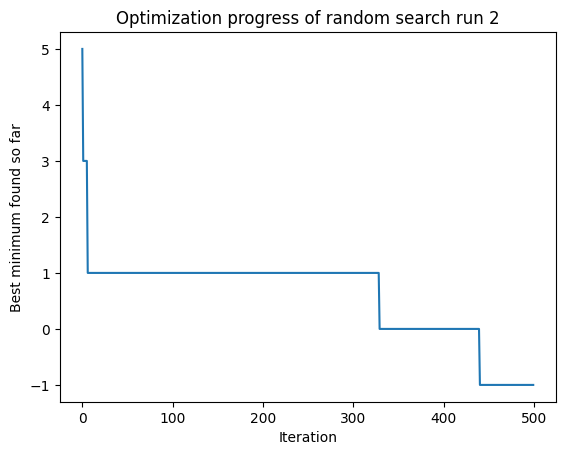

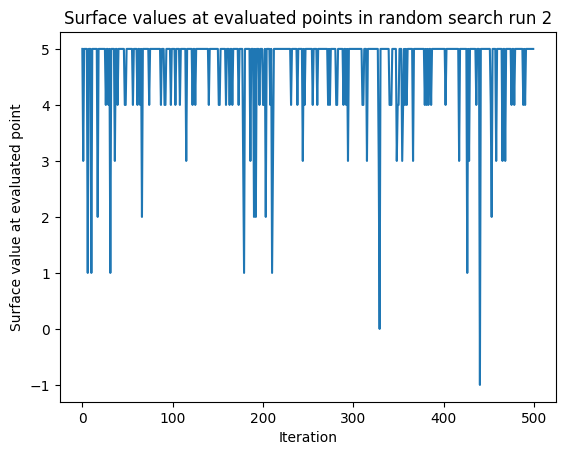

5.0


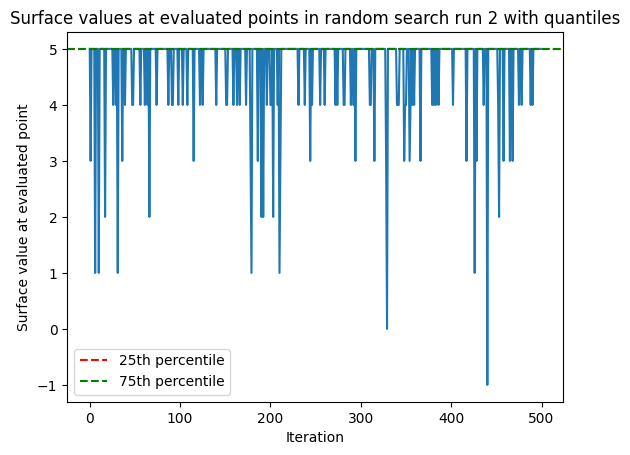

In [ ]:
#TO BE FILLED: Plot the optimization
first_run = results_per_run[0]

plot_random_search_run_results(first_run, 1)


# Compute the median, 25% quantile, and 75% quantile of the result runs


#### Simulated Annealing ####
A more advanced and more commonly used hyperparameter optimization algorithm is simulated annealing. Let us recapitulate the steps of this algorithm:

1. Initialize first state and temperature. As a first state, use grid position [0, 0, 0, 0].
2. Iterate over the step number until the maximum is reached. In each iteration, perform the following steps:
 * Update temperature based on annealing schedule.
 * Select a random neighbor of the current state.
 * Evaluate the energy of the system in the current state and in the selected neighboring state.
 * Evaluate the acceptance probability function P.
 * Obtain a random number R between 0 and 1.
 * If P ≥ R, select the random neighbor as current state, otherwise do nothing.
 * Continue with the next iteration.
3. Read the results.

Accordingly, for simulated annealing, we need to implement the following components.

* Annealing schedule: It determins how to temperature progresses with the number of iterations $n$. For the sake of simplicity, we will implement a simple annealing schedule according to the following formula that also depends on the total number of iterations $N$: $T(n) = 0.4 - 0.25 \cdot \frac{n+1}{N}$
* Grid index to position converter: We need to convert grid indices to grid positions. For instance, grid index 19 of axis a corresponds to a grid position of 1.0 as it is the last allowed index on that axis.
* Neighbor selection: We need a method to determine a random neighbor. Here, a neighbor is defined as any point on the grid that has an index that is higher or lower by up to 2 in any of the dimensions. This can be the case for only one dimension but also for all 4 dimensions. Importantly, we need to make sure that we only consider existing neighbors and not neighbours outside our grid.
* Energy evaluation: The energy of the system corresponds to the value of the optimization surface.
* Acceptance probability function: if $E' \geq E$, $P(E, E', T) = e^{-\frac{E'-E}{T}}$, otherwise $P = 1$.


Use the following code cell to implement simulated annealing on our toy optimization surface. Once you have your implementation, repeat the simulated annealing run at least 10 times. Importantly, use 300 as the maximum number of iterations for simulated annealing.

In [ ]:
#TO BE FILLED: Perform simulated annealing

Create two plots based on the results. First, for one individual simulated annealing run, show the actual optimization trajectory, that is all the accepted energy values as a function of the iteration number. In the same plot, also add the temperature as a function of the iteration number. Use the following code cell for this plot.

In [ ]:
#TO BE FILLED: Plot the optimization trajectory of one individual simulated annealing run

Secondly, aggregate the results of all the simulated annealing runs in the same way as you did for the random search. To repeat the corresponding instructions explicitly, plot the curve that shows the best minimum found as a function of the number of iterations. This should be done by aggregating the inidividual optimization trajectories, modifying them to always show the best minimum found until that specific iteration, and taking the median optimization progress and both the 25 % and 75 % percentile optimization curves. Like above, the median and both the 25 % and 75 % percentile optimization curves should be visualized in a plot. Also include the results from the random search in this plot which allows us to directly compare the efficiency of these two hyperparameter optimization algorithms.

In [ ]:
#TO BE FILLED: Plot the best optimization value found against the number of iterations and compare simulated annealing with random search

#### 1.2 Electronic Energy of Dihydrogen

Having implemented and compared both random search and simulated annealing, we can now use one of these hyperparameter optimization algorithms to optimize the hyperparameters of an artificial neural network. We will use the PyTorch package for this. The problem we will tackle is the prediction of the eletronic energy of dihydrogen, both in the ground state and in the first excited state, as a function of the interatomic distance between the two hydrogen atoms.

We start by downloading the reference dataset that we will use for training. We use the package gdown as the dataset is stored on Google Drive. Subsequently, we read the data into python.

In [ ]:
# Download dihydrogen dataset from Google Drive with gdown
! gdown 1CX-cEcyoX_KaI_DzWMcXeSrF17et1-qF

In [ ]:
# Load dataset from file
dataset = nc.Dataset('dihydrogen.nc')

# Read out data of interest
data = pd.DataFrame()
data['distance'] = np.arange(0.25, 5.05, 0.05)
data['energy_0'] = dataset['energy'][:,0] - np.amin(dataset['energy'][:,0]) # relative ground state energies
data['energy_1'] = dataset['energy'][:,1] - np.amin(dataset['energy'][:,0]) # relative first excited state energies

To get a first idea of the available data, create a plot that illustrates both the relative ground state and first excited state energies as a function of the dihydrogen bond distance.

In [ ]:
#TO BE FILLED: Plot both energy_0 and energy_1 against the corresponding bond distance

To prepare the data for training an artificial neural network, we need to preprocess the data and split it into training and validation set. This is done in the following code cell for you.

In [ ]:
# Set up features and target arrays with proper shape
features = data['distance'].values.reshape(-1, 1)
targets = np.stack((data['energy_0'].values, data['energy_1'].values), axis=1)

# Split dataset into training, validation and holdout data (80/20)
features_train_unscaled, features_validation_unscaled, targets_train_unscaled, targets_validation_unscaled = skms.train_test_split(features, targets, test_size=0.20, random_state=0) # data split

# Scale features
scaler_features = skpp.MinMaxScaler()
scaler_features.fit(features_train_unscaled) # it is important to scale based on the training data, not based on the full data
features_train = scaler_features.transform(features_train_unscaled)
features_validation = scaler_features.transform(features_validation_unscaled)

# Scale target values
scaler_targets = skpp.MinMaxScaler()
scaler_targets.fit(targets_train_unscaled)
targets_train = scaler_targets.transform(targets_train_unscaled)
targets_validation = scaler_targets.transform(targets_validation_unscaled)

Next, we define a class for our neural network with all the hyperparameters of interest. This class also creates the neural network architecture (number of layers, number of nodes per layer) based on some of the hyperparameters. This is done in the following code cell.

In [ ]:
class NeuralNetwork(tc.nn.Module):
  def __init__(self, input_size, hidden_size, hidden_layers, activation_function, dropout_rate):
    # Run the initialization from the tc.nn.Module class
    super().__init__()

    # Define neural network architecture
    self.net = tc.nn.Sequential(
      tc.nn.Linear(input_size, hidden_size), # this is a fully connected linear transformation with the input features
      activation_function, # this is the activation function to be used that is applied after the linear transformation
      tc.nn.Dropout(p=dropout_rate), # this implements dropout for this layer by stochastically dropping a certain percentage of the nodes
    )
    if hidden_layers > 1:
      for li in range(hidden_layers - 1):
        self.net.append(tc.nn.Linear(hidden_size, hidden_size))
        self.net.append(activation_function)
        self.net.append(tc.nn.Dropout(p=dropout_rate))
    self.net.append(tc.nn.Linear(hidden_size, 2)) # this is the final layer that provides two numbers as output, the energies of interest
    return

  def forward(self, y_in):
    # Define forward pass
    return self.net(y_in)

The next step is to define a function that takes the hyperparameters as input and uses them to set up an artificial neural network, train it, and evaluate the validation loss at the end. The function returns the validation loss and the corresponding neural network. Importantly, we do not directly return the validation loss but the natural logarithm of it. This is because the natural logarithm of the validation loss is better suited as target property to be optimized. Accordingly, we will use the natural logarithm of the validation loss as our 'energy' in the simulated annealing algorithm. Note that the function evaluate_validation_loss takes a dictionary of hyperparameters as input.




In [ ]:
# Create validation data instance
validation_dataset = skch.predefined_split(skcd.Dataset(tc.as_tensor(features_validation.astype(np.float32)), tc.as_tensor(targets_validation.astype(np.float32))))

# Define function to train neural network and return final validation loss
def evaluate_validation_loss(hyperparameters):
# Define skorch model to interface sklearn
  model = skc.NeuralNet(
      module = NeuralNetwork,
      module__input_size = features_train.shape[1],
      module__hidden_size = hyperparameters['hidden_size'],
      module__hidden_layers = hyperparameters['hidden_layers'],
      module__activation_function = hyperparameters['activation_function'],
      module__dropout_rate = hyperparameters['dropout_rate'],
      train_split = validation_dataset, # define validation dataset explicitly
      criterion = hyperparameters['loss_function'],
      max_epochs = hyperparameters['maximum_epochs'],
      batch_size = hyperparameters['batch_size'],
      optimizer = tco.Adam,
      lr = hyperparameters['learning_rate'],
      iterator_train__shuffle = True,
  )

  # Train skorch model
  model.fit(
      X = tc.as_tensor(features_train.astype(np.float32)),
      y = tc.as_tensor(targets_train.astype(np.float32))
  )

  # Get model history
  model_history = model.history

  # Determine natural logarithm of final validation loss
  validation_loss = np.log(model_history[-1, 'valid_loss'])

  return validation_loss, model

Next, we define the grid that we will use for hyperparameter optimization. Compare this grid definition to the very beginning of the toy problem above. You will see that hyperparameter optimization here is analogous to the toy problem. The only difference is in the definition of the allowed grid positions on each dimension, where we need to make sure that for each hyperparameter we want to consider, we have meaningful grid positions. To limit the optimization space, we consider only 4 hyperparameters, namely the number of nodes per hidden layer, the number of hidden layers, the learning rate, and the nonlinear activation function. The following code cell defines the allowed grid positions for each of these hyperparameters.

In [ ]:
# Define grid by number of grid points on each axis
n_a = 20 # number of nodes per hidden layer
n_b = 6 # number of hidden layers
n_c = 14 # number of learning rate values
n_d = 4 # number of nonlinear activation functions

# Define allowed grid positions on each dimension
a = np.array([5 * (ni + 1) for ni in range(n_a)])
b = np.array(range(1, n_b + 1))
c = np.array([0.5 ** (ni) for ni in range(n_c)])
d = [tc.nn.ReLU(), tc.nn.GELU(), tc.nn.Tanh(), tc.nn.Sigmoid()]
grid_list_dihydrogen = [a, b, c, d]

Additionally, we require a function that maps grid position indices to the actual hyperparameters. This is provided for you in the following code cell. The function takes the current grid position as input and returns a dictionary of hyperparameters corresponding to the respective grid positions. The returned dictionary can be directly used as input for the function evaluate_validation_loss.

In [ ]:
# Define function to get hyperparameters from grid
def get_hyperparameters(current_index):
  # Unpack current_index
  ai, bi, ci, di = current_index

  # Get hyperparameters frim grid position
  hidden_size = grid_list_dihydrogen[0][ai]
  hidden_layers = grid_list_dihydrogen[1][bi]
  learning_rate = grid_list_dihydrogen[2][ci]
  activation_function = grid_list_dihydrogen[3][di]

  # Define dictionary of hyperparameters
  hyperparameters = {
    'hidden_size': hidden_size,
    'hidden_layers': hidden_layers,
    'activation_function': activation_function,
    'learning_rate': learning_rate,
    'loss_function': tc.nn.MSELoss(),
    'dropout_rate': 0.2, # fixed hyperparameter
    'batch_size': 20, # fixed hyperparameter
    'maximum_epochs': 25, # fixed hyperparameter
  }
  return hyperparameters

Here is an example of how you can use these functions to set up and train a neural network, and obtain the logarithmic validation loss, that is the natural logarithm of the validation loss.

In [ ]:
# Define grid position
current_index = [0, 0, 0, 0]

# Train model and obtain final results
logarithmic_validation_loss, neural_network = evaluate_validation_loss(get_hyperparameters(current_index))

# Print final results
print('Final validation loss: {}'.format(np.exp(logarithmic_validation_loss)))

To visualize the prediction performance of the corresponding model, first, you have to use the model to make predictions for both the training and the validation data. This is demonstrated in the following code cell.

In [ ]:
# Make predictions with the models
predictions_train = scaler_targets.inverse_transform(neural_network.predict(features_train.astype(np.float32)))
predictions_validation = scaler_targets.inverse_transform(neural_network.predict(features_validation.astype(np.float32)))

With the model predictions in hand, it is now your task to create a plot that compares the predictions of this first model (corresponding to a current_index of [0, 0, 0, 0]) against the original data. Plot the relative electronic energy in Hartree against the bond distance in dihydrogen and show both the reference values, the predictions of the training data, and the predictions of the validation data. Use the following code cell to create this plot.

In [ ]:
#TO BE FILLED: Plot the model predictions for both the training and the validation data and compare them against the original dataset


With this, we have everything to use simulated annealing to optimize the hyperparameters of an artificial neural network that predicts the relative electronic energy of both the ground state and the first excited state of dihyrogen as a function of the dihydrogen bond distance. Unlike the toy problem, energy evaluation is relatively expensive as this requires training an artificial neural network. Therefore, only run simulated annealing once, and not 10 times like in the toy problem. Additionally, it is sufficient to run 50 iterations. This should take approximately 15 minutes, depending on your actual implementation. Use the same annealing schedule, neighbor selection radius (everything with an index difference up to 2 is considered a neighbor), and acceptance probability function as for the toy problem. Use the following code cell for your implementation and use as many code cells as you think is appropriate.

In [ ]:
#TO BE FILLED: Perform hyperparameter optimization via simulated annealing

With a full optimization run in hand, plot the optimization trajectory of simulated annealing together with the temperature as a function of the iteration number.

In [ ]:
#TO BE FILLED: Plot the optimization trajectory of your simulated annealing hyperparameter optimization

Illustrate the performance of the final model that you found by plotting the corresponding model predictions and the original reference values in a plot of the relative electronic energy in Hartree against the corresponding dihydrogen bond distance in angstrom.

In [ ]:
#TO BE FILLED: Plot the model predictions for both the training and the validation data and compare them against the original dataset for your final model

Finally, print the specific hyperparameters that your final model uses. Use the following code cell for that.

In [ ]:
#TO BE FILLED: Print the hyperparameters your final model uses

### 2. Assignment

#### 2.1 Toy Problem

1. How could the standard grid search be modified to reduce the number of necessary evaluations?
2. How many iterations does it typically take in the random search to find the true minimum on the toy optimization surface?
3. How does the simulated annealing algorithm you implemented compare to random search in terms of the best value reached as a function of optimization steps? Pay particular attention to different regimes.
4. How could you improve the simulated annealing algorithm further to find better values with less optimization steps?

#### 2.2 Electronic Energy of Dihydrogen

1. What are the allowed grid positions for each of the hyperparameters that we optimize over? How many possible points exist on that grid?
2. Based on the plot of the predictions of the final model, how good would you say does your model perform? If applicable, are there any parts of the data the model struggles with?
3. How could you obtain models with even better performance? Also take the computer resources required into account.
4. From the hyperparameters that we chose not to optimize, which do you think has the largest impact on the prediction performance? Provide a justification for your answer.



ANSWERS:

SOURCES:

Disclose all your sources and support tools here.